# Pipeline preditivo completo para classificação de dígitos manuscritos com o dataset MNIST.

## Fase 1 - Carregamento e Análise Exploratória de Imagens (EDA)

Nesta etapa será realizado o carregamento e a análise inicial do dataset MNIST, buscando compreender sua estrutura e características antes do pré-processamento dos dados.

Serão executadas as seguintes ações:

* Carregamento do dataset MNIST;
* Verificação das dimensões e quantidade de imagens;
* Identificação das classes e análise da distribuição dos dígitos;
* Verificação do balanceamento entre as classes;
* Visualização de exemplos dos dígitos de 0 a 9 em uma grade 2×5;
* Análise da representação das imagens em 28×28 pixels e 784 features;
* Análise da escala de intensidade dos pixels, de 0 a 255;
* Geração e armazenamento das visualizações utilizadas na análise exploratória.


In [1]:
#Bibliotecas do projeto.

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np

In [2]:
#Importação das funções do projeto.

from src.carregamento import carregar_dataset
from src.analise_exploratoria import inspecionar_dados, visualizar_digitos
from src.tratamento_de_dados import dividir_dados, verificar_dimensoes, verificar_distribuicao_classes

In [3]:


X, y = carregar_dataset()

Baixando o dataset MNIST...
O Dataset MNIST foi carregado com sucesso!


### Inspeção inicial dos dados

Nesta etapa será realizada uma inspeção inicial do dataset para compreender sua estrutura, quantidade de imagens, número de features, classes existentes e distribuição dos exemplos entre os dígitos.

In [4]:

inspecionar_dados(X, y)


============================== Inspeção inicial do dataset ==============================

============================== Dimensão de x==============================
(70000, 784)

============================== Dimensão de y==============================
(70000,)

============================== Quantidade de imagens ==============================
70000

============================== Quantidade de features por imagem ==============================
784

============================== Quantidade de classes ==============================
10

============================== Distribuição das classes ==============================
Classe 0: 6903 imagens
Classe 1: 7877 imagens
Classe 2: 6990 imagens
Classe 3: 7141 imagens
Classe 4: 6824 imagens
Classe 5: 6313 imagens
Classe 6: 6876 imagens
Classe 7: 7293 imagens
Classe 8: 6825 imagens
Classe 9: 6958 imagens

============================== Análise do balanceamento ==============================
Classe com mais imagens: 1 (7877 imagens)
Classe 

### Análise da Inspeção Inicial dos Dados

Durante a inspeção inicial foi identificado que o dataset MNIST possui **70.000 imagens**, representadas por **784 features** cada, e **10 classes**, correspondentes aos dígitos de 0 a 9.

Cada imagem possui dimensão original de **28×28 pixels**.

Para utilização nos modelos de aprendizado de máquina, essas imagens são representadas como vetores contendo 784 valores, resultado da transformação de 28×28 pixels em uma única dimensão.

A variável `y` contém os rótulos correspondentes às imagens, apresentando as classes de 0 a 9. A análise da distribuição identificou diferenças na quantidade de exemplos entre as classes.

A classe 1 possui a maior quantidade de imagens, com **7.877 registros**, enquanto a classe 5 possui a menor quantidade, com **6.313 registros**.

A diferença entre a classe com maior e menor quantidade é de **1.564 imagens**.

Apesar dessa diferença, a distribuição das classes não apresenta uma concentração extrema em uma única classe, indicando que o dataset possui um **balanceamento razoável**.



### Visualização dos dígitos do dataset


Nesta etapa serão visualizados exemplos dos dígitos de 0 a 9, organizados em uma grade 2×5.

A visualização permite observar como as imagens estão representadas no dataset e confirmar a correspondência entre os pixels e seus respectivos rótulos.


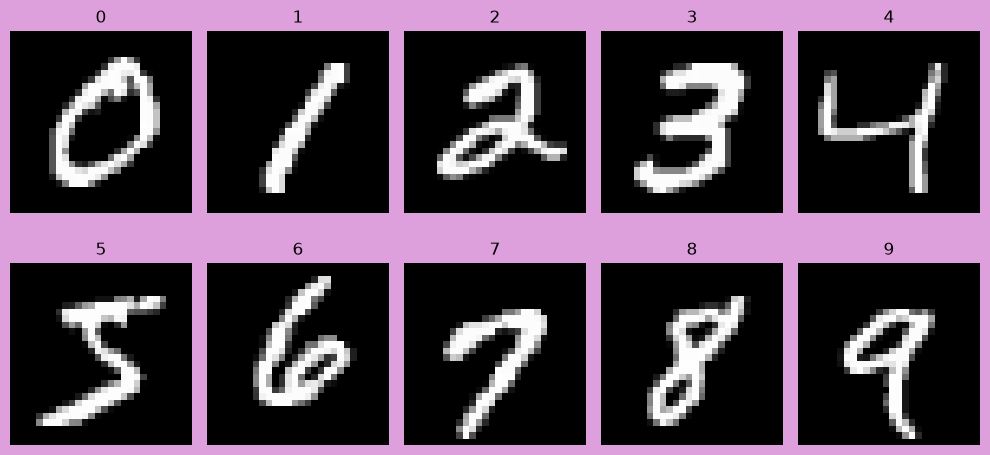

In [5]:
visualizar_digitos(X, y)

### Interpretação da visualização

A visualização apresenta exemplos das dez classes do dataset MNIST, correspondentes aos dígitos de 0 a 9. 

As imagens são representadas em uma matriz de **28×28 pixels** e apresentadas em escala de cinza.

Cada imagem possui **784 valores de pixels**, pois 28 × 28 = 784.

No dataset original, esses valores representam diferentes intensidades de cinza, variando de **0 a 255**, sendo que valores mais baixos representam regiões mais escuras e valores mais altos representam regiões mais claras.

A visualização também permite observar que existem diferenças na forma como cada dígito é escrito, mesmo pertencendo à mesma classe.

Essa variação entre as imagens é uma característica importante do problema de classificação, pois os modelos deverão aprender os padrões que permitem diferenciar os dígitos mesmo quando eles apresentam diferentes estilos de escrita.

A grade 2×5 facilita a inspeção das dez classes e confirma visualmente a correspondência entre as imagens e seus respectivos rótulos.


## **Fase 2 - Pipeline de Pré-processamento e Divisão dos Dados**

Nesta etapa será realizado o pré-processamento e a preparação do dataset MNIST para as etapas posteriores de treinamento e avaliação dos modelos de classificação.

Serão executadas as seguintes ações:

* Divisão do dataset em conjuntos de treino, validação e teste;

* Utilização da estratificação por classe para preservar a distribuição dos dígitos nos diferentes conjuntos;

* Definição da proporção de 70% para treino, 10% para validação e 20% para teste;

* Verificação das dimensões e quantidade de amostras presentes em cada conjunto;

* Verificação da distribuição das classes após a divisão dos dados;

* Normalização dos valores de intensidade dos pixels para o intervalo [0,0, 1,0];

* Verificação dos valores mínimos e máximos após a normalização;

* Garantia da separação adequada entre os dados utilizados no treinamento, validação e teste, evitando data leakage;



### Divisão dos dados

Nesta etapa será realizada a divisão do dataset MNIST em conjuntos de treino, validação e teste, utilizando estratificação por classe.

A divisão será feita na proporção de 70% para treino, 10% para validação e 20% para teste, garantindo que a distribuição dos dígitos de 0 a 9 seja preservada entre os diferentes conjuntos.


In [6]:
(
    X_treino,
    X_validacao,
    X_teste,
    y_treino,
    y_validacao,
    y_teste
) = dividir_dados(X, y)

In [7]:
verificar_dimensoes(
    X_treino,
    X_validacao,
    X_teste,
    y_treino,
    y_validacao,
    y_teste
)

Dimensões dos conjuntos:
X treino: (49000, 784)
X validação: (7000, 784)
X teste: (14000, 784)

Dimensões dos rótulos:
y treino: (49000,)
y validação: (7000,)
y teste: (14000,)


In [8]:
verificar_distribuicao_classes(
    y_treino,
    y_validacao,
    y_teste
)

Distribuição das classes:

Classe    Treino      % Treino    Validação     % Validação   Teste       % Teste   
0         4832        9.86        690           9.86          1381        9.86      
1         5514        11.25       788           11.26         1575        11.25     
2         4893        9.99        699           9.99          1398        9.99      
3         4999        10.20       714           10.20         1428        10.20     
4         4777        9.75        682           9.74          1365        9.75      
5         4419        9.02        631           9.01          1263        9.02      
6         4813        9.82        688           9.83          1375        9.82      
7         5105        10.42       729           10.41         1459        10.42     
8         4777        9.75        683           9.76          1365        9.75      
9         4871        9.94        696           9.94          1391        9.94      


### **Conclusão da divisão**

A distribuição das classes foi preservada de forma consistente entre os conjuntos de treino, validação e teste.

As proporções das classes apresentam diferenças mínimas entre os conjuntos, confirmando que a estratificação utilizada funcionou conforme o esperado.

Dessa forma, os conjuntos permanecem representativos da distribuição original do dataset MNIST, evitando uma concentração desproporcional de determinadas classes em algum dos conjuntos.
